# SBI for Solar System Acceleration from Gaia QSO Proper Motions

**Pipeline:**
1. Prior: θ = {alm for ℓ ≤ 3 (30 params), Cℓ for ℓ = 4–10 (14 params: E+B separate)} → 44-dim
2. Forward model: synthesize noisy HEALPix PM maps → VSH fit (lmax=10) → summary x (240-dim)
3. SNPE on 5000 (θ, x) pairs → posterior over θ conditioned on real Gaia summary
4. Extract (gx, gy, gz) from the l=1 dipole of posterior samples

Also runs a **deterministic-only** model (θ = 30-dim alm only, no stochastic Cl).

In [1]:
import numpy as np
import healpy as hp
import math
import matplotlib.pyplot as plt
import corner
import torch
from astropy.coordinates import SkyCoord
import astropy.units as u
import pandas as pd

from sbi.inference import SNPE
from sbi import utils as utils
from sbi.utils.user_input_checks import check_sbi_inputs, process_prior, process_simulator
from sbi.inference import simulate_for_sbi

from scipy.linalg import lu_factor, lu_solve

import matplotlib as mpl


mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'text.latex.preamble': r'\usepackage{newtxtext}\usepackage{newtxmath}',
})

from sbi_hpm.geometry import SkyFunction
from sbi_hpm.pixelization import Pixelize
from sbi_hpm.data import load_gaia_qso, compute_pixel_stats, make_galactic_mask
from sbi_hpm.forward_model import WeightedSHT
from sbi_hpm.sbi_setup import (
    n_real_params, build_full_alm_complex, build_det_alm_complex,
    precompute_noise_cholesky, generate_pixel_noise,
    create_prior_full, create_prior_det,
    simulator_full, simulator_det,
)
from sbi_hpm.diagnostics import marginal_coverage, run_tarp_test, extract_g_tarp, extract_g_theta
from sbi_hpm import plotting

/home/phuy2808/Astrophysis/Intern_apc/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Gaia Data and Compute Pixel Statistics

In [ ]:
gaia = pd.read_csv('gaia_qso_edata_5_params.csv')


ra       = gaia['ra'].values
dec      = gaia['dec'].values
pmra     = gaia['pmra'].values
pmdec    = gaia['pmdec'].values
sig_pmra  = gaia['pmra_error'].values
sig_pmdec = gaia['pmdec_error'].values
pm_corr   = gaia['pmra_pmdec_corr'].values

print(f"Sources after cuts: {len(ra):,}")

Sources after cuts: 1,215,942


In [3]:
nside = 64
pixelize = Pixelize(nside)
skyfunc  = SkyFunction(nside)

theta_src = np.radians(90 - dec)
phi_src   = np.radians(ra)

npix       = hp.nside2npix(nside)
pix_idx    = np.arange(npix)
theta_g, phi_g = hp.pix2ang(nside, pix_idx, lonlat=False)
ra_g   = phi_g * 180. / np.pi
dec_g  = 90. - theta_g * 180. / np.pi

icrs    = SkyCoord(ra_g * u.deg, dec_g * u.deg, frame='icrs')
gal     = icrs.galactic
mask_galactic = np.abs(gal.b.deg) > 0

# Pixel-level weighted-mean proper motions
n_pix = pixelize.sum_in_pixels(theta_src, phi_src)

gaia_pmra_wm  = pixelize.calculate_weighted_means(theta_src, phi_src, pmra,  sig_pmra)
gaia_pmdec_wm = pixelize.calculate_weighted_means(theta_src, phi_src, pmdec, sig_pmdec)

sw_ra  = pixelize.sum_in_pixels(theta_src, phi_src, weights=1 / sig_pmra**2)
sw_dec = pixelize.sum_in_pixels(theta_src, phi_src, weights=1 / sig_pmdec**2)

gaia_sig_pmra_wm  = np.sqrt(1 / sw_ra)
gaia_sig_pmdec_wm = np.sqrt(1 / sw_dec)

cinv_rd = pixelize.sum_in_pixels(theta_src, phi_src,
              weights=pm_corr / (sig_pmra * sig_pmdec))
with np.errstate(invalid='ignore'):
    gaia_pm_corr_wm = np.where(
        (sw_ra > 0) & (sw_dec > 0),
        cinv_rd / np.sqrt(sw_ra * sw_dec),
        0.0
    )
mask_gaia = (
    (gaia_pmra_wm  != 0) & (gaia_pmdec_wm  != 0) &
    np.isfinite(gaia_sig_pmra_wm) & np.isfinite(gaia_sig_pmdec_wm) &
    mask_galactic
)

print(f"Valid pixels: {mask_gaia.sum()} / {npix}")

Valid pixels: 43182 / 49152


/tmp/ipykernel_298655/1457720979.py:27: RuntimeWarning: divide by zero encountered in divide
  gaia_sig_pmra_wm  = np.sqrt(1 / sw_ra)
/tmp/ipykernel_298655/1457720979.py:28: RuntimeWarning: divide by zero encountered in divide
  gaia_sig_pmdec_wm = np.sqrt(1 / sw_dec)


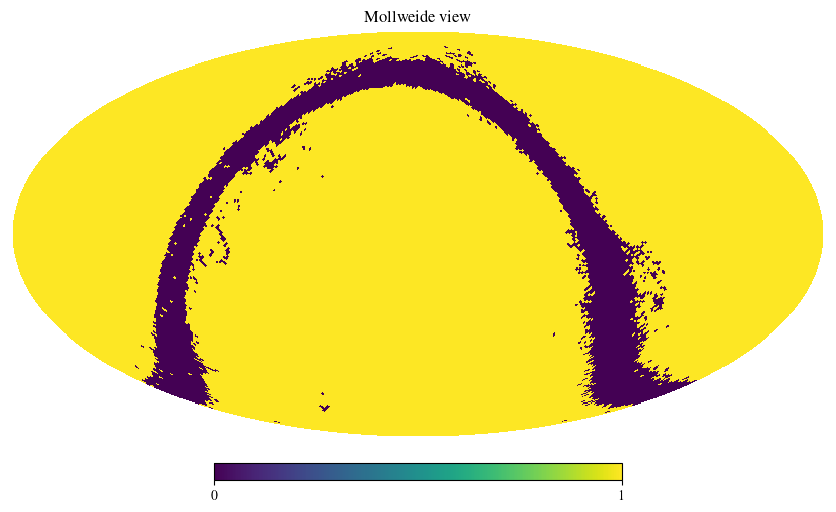

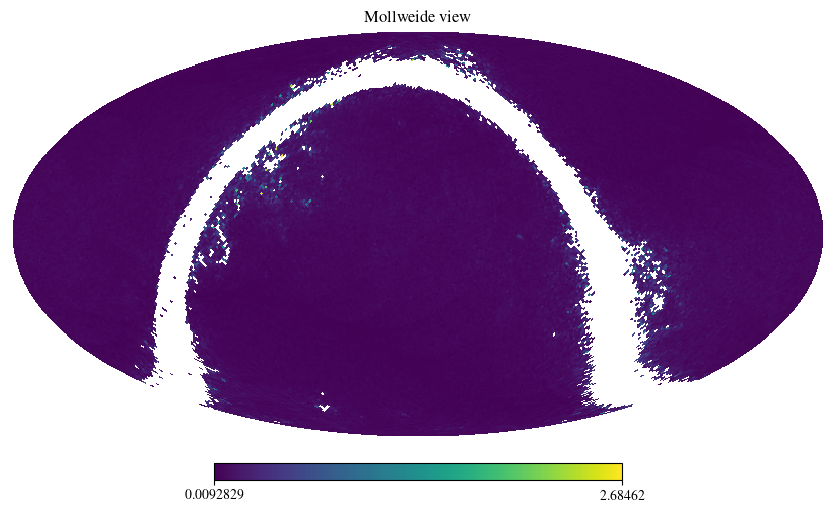

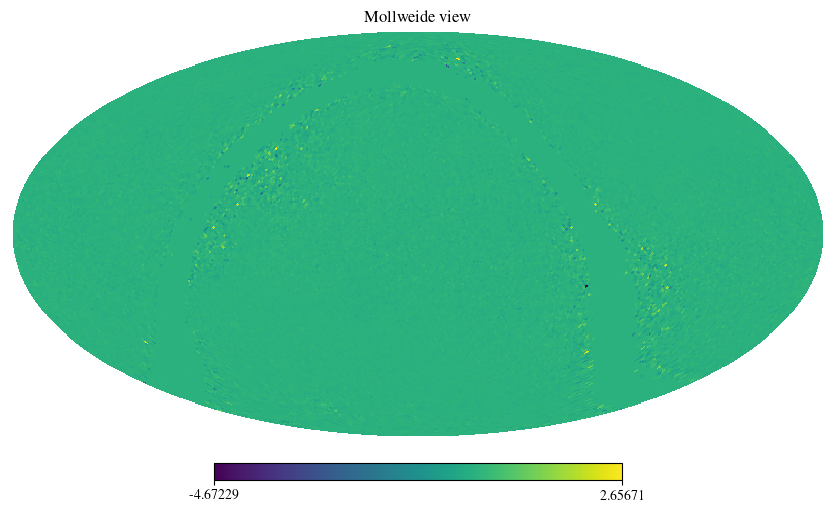

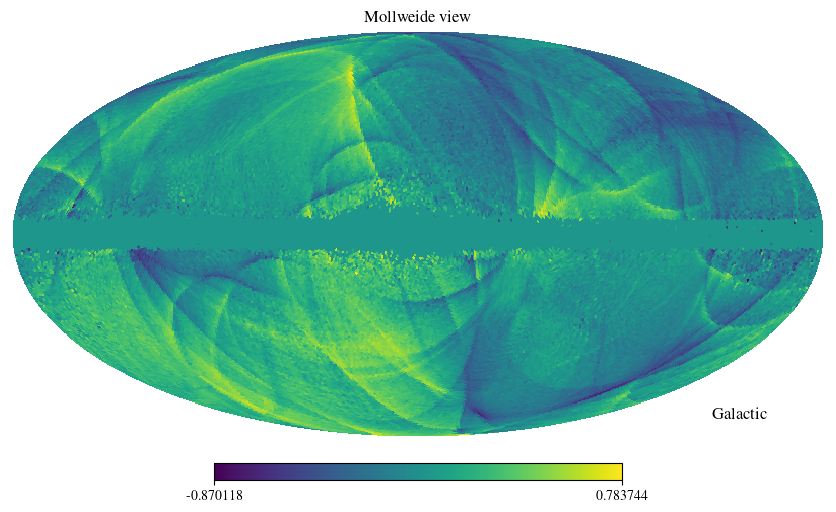

In [9]:
hp.mollview(mask_gaia)
hp.mollview(gaia_sig_pmra_wm)
hp.mollview(gaia_pmra_wm*mask_gaia)
hp.mollview(gaia_pm_corr_wm, coord = ['C', 'G'])

In [5]:
def pixelize_full_covariance(theta, phi, pmra, pmdec,
                              sig_pmra, sig_pmdec, pm_corr, nside):
    npix = hp.nside2npix(nside)
    indices = hp.ang2pix(nside, theta, phi)

    # Per-source inverse covariance components
    factor = 1.0 / (1.0 - pm_corr**2)
    Cinv_rr = factor / sig_pmra**2
    Cinv_rd = -factor * pm_corr / (sig_pmra * sig_pmdec)
    Cinv_dd = factor / sig_pmdec**2

    # Accumulate into pixels
    Cinv_rr_pix = np.bincount(indices, weights=Cinv_rr, minlength=npix)
    Cinv_rd_pix = np.bincount(indices, weights=Cinv_rd, minlength=npix)
    Cinv_dd_pix = np.bincount(indices, weights=Cinv_dd, minlength=npix)

    # Weighted sum: sum_i Sigma_i^{-1} mu_i
    sum_wr = np.bincount(indices,
                          weights=Cinv_rr*pmra + Cinv_rd*pmdec,
                          minlength=npix)
    sum_wd = np.bincount(indices,
                          weights=Cinv_rd*pmra + Cinv_dd*pmdec,
                          minlength=npix)

    # Invert pixel covariance analytically
    det = Cinv_rr_pix * Cinv_dd_pix - Cinv_rd_pix**2
    valid = det > 0
    Sigma_rr = np.where(valid,  Cinv_dd_pix / det, 0.0)
    Sigma_rd = np.where(valid, -Cinv_rd_pix / det, 0.0)
    Sigma_dd = np.where(valid,  Cinv_rr_pix / det, 0.0)

    # Weighted mean proper motion
    pmra_pix  = Sigma_rr * sum_wr + Sigma_rd * sum_wd
    pmdec_pix = Sigma_rd * sum_wr + Sigma_dd * sum_wd

    # Effective pixel uncertainties and correlation
    sig_pmra_pix  = np.where(valid, np.sqrt(np.maximum(Sigma_rr, 0.0)), 0.0)
    sig_pmdec_pix = np.where(valid, np.sqrt(np.maximum(Sigma_dd, 0.0)), 0.0)
    denom = sig_pmra_pix * sig_pmdec_pix
    pm_corr_pix = np.where(denom > 0, Sigma_rd / denom, 0.0)

    return pmra_pix, pmdec_pix, sig_pmra_pix, sig_pmdec_pix, pm_corr_pix


gaia_pmra_full, gaia_pmdec_full, gaia_sig_pmra_full, gaia_sig_pmdec_full, gaia_pm_corr_full = pixelize_full_covariance(
    theta_src, phi_src, pmra, pmdec, sig_pmra, sig_pmdec, pm_corr, nside
)  

/tmp/ipykernel_298655/3623140346.py:28: RuntimeWarning: invalid value encountered in divide
  Sigma_rr = np.where(valid,  Cinv_dd_pix / det, 0.0)
/tmp/ipykernel_298655/3623140346.py:29: RuntimeWarning: invalid value encountered in divide
  Sigma_rd = np.where(valid, -Cinv_rd_pix / det, 0.0)
/tmp/ipykernel_298655/3623140346.py:30: RuntimeWarning: invalid value encountered in divide
  Sigma_dd = np.where(valid,  Cinv_rr_pix / det, 0.0)
/tmp/ipykernel_298655/3623140346.py:40: RuntimeWarning: invalid value encountered in divide
  pm_corr_pix = np.where(denom > 0, Sigma_rd / denom, 0.0)


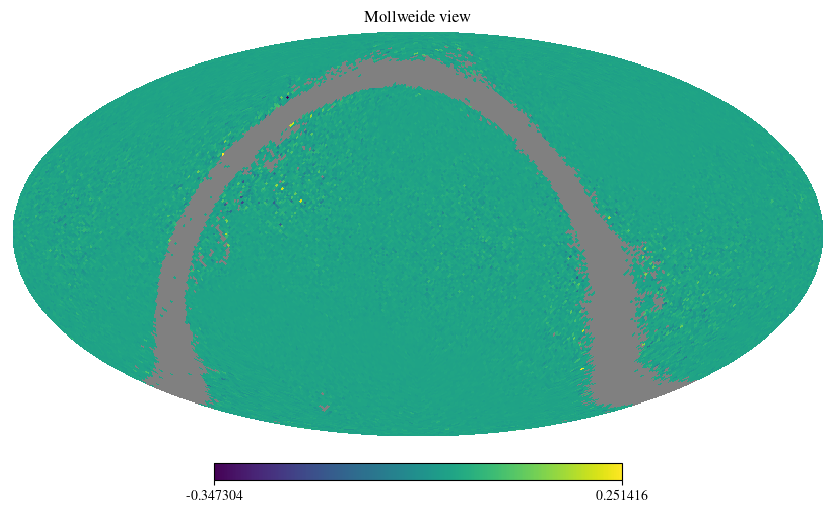

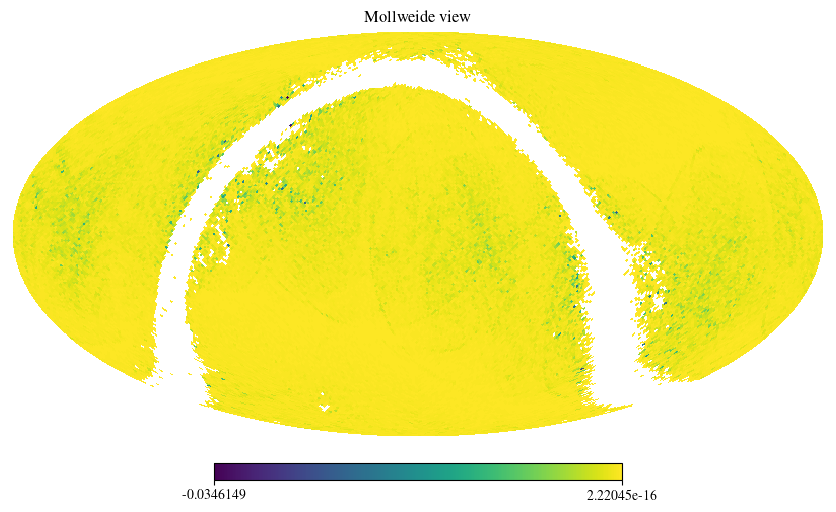

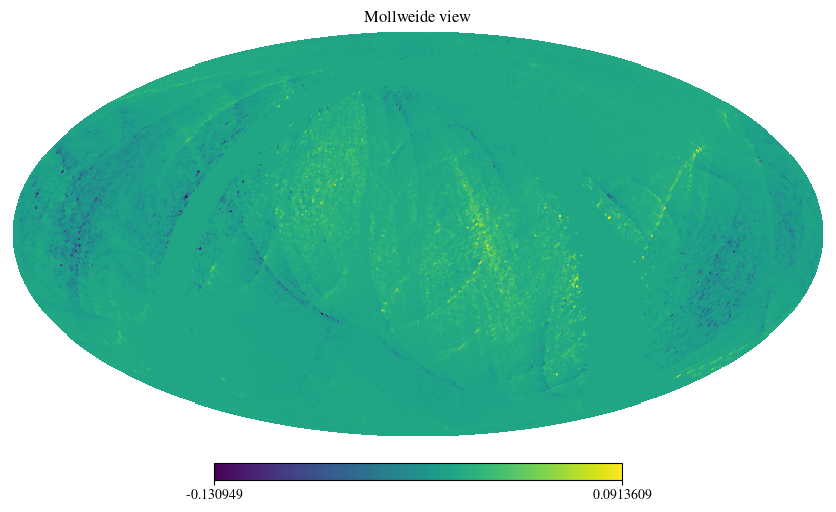

In [6]:
diff_pmra = np.full(npix, hp.UNSEEN)
diff_pmra[mask_gaia] = gaia_pmra_full[mask_gaia] - gaia_pmra_wm[mask_gaia]
hp.mollview(diff_pmra)
hp.mollview(gaia_sig_pmra_full - gaia_sig_pmra_wm)
hp.mollview(gaia_pm_corr_full - gaia_pm_corr_wm)  

## 2. SBI Dimensions and Prior

| Block | Content | Size |
|-------|---------|------|
| θ[:30] | alm (E+B) for ℓ = 1, 2, 3 | 30 |
| θ[30:37] | Cl_E for ℓ = 4…10 | 7 |
| θ[37:44] | Cl_B for ℓ = 4…10 | 7 |
| **θ total** | | **44** |
| x | best-fit alm (lmax=10 VSH fit) | 240 |

In [ ]:
lmax_sig = 3   # ℓ ≤ 3  : deterministic signal parameters in θ
lmax_fit = 10  # ℓ ≤ 10 : VSH fit used as summary statistic x

def n_real_params(lmax):
    """Number of real alm parameters (E+B) for a given lmax (spin-1, ℓ starts at 1)."""
    return 2 * ((lmax + 1) + (math.comb(lmax + 2, 2) - (lmax + 1)) * 2) - 2

n_alm_l3  = n_real_params(lmax_sig)        # 30
n_Cl      = 2 * (lmax_fit - lmax_sig)      # 14  (Cl_E[4..10] + Cl_B[4..10])
n_theta   = n_alm_l3 + n_Cl               # 44
n_summary = n_real_params(lmax_fit)        # 240

# Deterministic-only model: no stochastic Cl — θ = alm for ℓ ≤ 3 only
n_theta_det = n_alm_l3   # 30

print(f"θ dimension (full model) : {n_theta}  ({n_alm_l3} alm_l≤3  +  {n_Cl} Cl_4..10 [E & B separate])")
print(f"θ dimension (det. only)  : {n_theta_det}  (alm_l≤3 only, no stochastic modes)")
print(f"Summary dimension        : {n_summary}")

θ dimension (full model) : 44  (30 alm_l≤3  +  14 Cl_4..10 [E & B separate])
θ dimension (det. only)  : 30  (alm_l≤3 only, no stochastic modes)
Summary dimension        : 240


In [79]:
# Units: all internal values in mas/yr
# alm  ∈ [-20, +20] µas/yr  →  [-0.020, +0.020] mas/yr
# Cl   ∈ [  0,  40] µas²/yr²  →  [0, 4e-5] (mas/yr)²

alm_bound = 60e-3   # mas/yr
Cl_bound  = 60e-6   # (mas/yr)²

# Full model: θ = [alm_l≤3 (30), Cl_E_4..10 (7), Cl_B_4..10 (7)]
low_full  = torch.cat([-alm_bound * torch.ones(n_alm_l3),
                        torch.zeros(n_Cl)])
high_full = torch.cat([ alm_bound * torch.ones(n_alm_l3),
                        Cl_bound  * torch.ones(n_Cl)])
prior_full = utils.BoxUniform(low=low_full, high=high_full)

# Deterministic-only model: θ = [alm_l≤3 (30)]  — no Cl parameters
low_det  = -alm_bound * torch.ones(n_theta_det)
high_det =  alm_bound * torch.ones(n_theta_det)
prior_det = utils.BoxUniform(low=low_det, high=high_det)

print(f"prior_full : θ ∈ R^{n_theta}  (alm + Cl_E + Cl_B)")
print(f"prior_det  : θ ∈ R^{n_theta_det}  (alm only)")

prior_full : θ ∈ R^44  (alm + Cl_E + Cl_B)
prior_det  : θ ∈ R^30  (alm only)


## 3. Build WeightedSHT Solver

The `WeightedSHT` class solves (Aᵀ C⁻¹ A) â = Aᵀ C⁻¹ d using `solve_pcg`.
The noise covariance C⁻¹ is set from the real Gaia per-pixel uncertainties.

In [80]:
# Replace non-finite noise values with 0 so they get zero weight in C⁻¹
# sig_pmra_safe  = np.where(np.isfinite(gaia_sig_pmra_wm),  gaia_sig_pmra_wm,  0.0)
# sig_pmdec_safe = np.where(np.isfinite(gaia_sig_pmdec_wm), gaia_sig_pmdec_wm, 0.0)
sig_pmra_safe  = np.where(np.isfinite(gaia_sig_pmra_full),  gaia_sig_pmra_full,  0.0)
sig_pmdec_safe = np.where(np.isfinite(gaia_sig_pmdec_full), gaia_sig_pmdec_full, 0.0)
pm_corr_safe   = np.nan_to_num(gaia_pm_corr_full, nan=0.0)

# base_solver = WeightedSHT(
#     nside, mask_gaia,
#     gaia_pmra_wm,  gaia_pmdec_wm,
#     sig_pmra_safe, sig_pmdec_safe, pm_corr_safe
# )

base_solver = WeightedSHT(
    nside, mask_gaia,
    gaia_pmra_full,  gaia_pmdec_full,
    sig_pmra_safe, sig_pmdec_safe, pm_corr_safe
)

print(f"WeightedSHT solver ready for lmax_fit={lmax_fit}")
print(f"Summary vector dimension: {n_summary}")

WeightedSHT solver ready for lmax_fit=10
Summary vector dimension: 240


In [81]:


def build_lu(lmax):
    n = n_real_params(lmax)
    print(f"Building {n}×{n} normal matrix for lmax={lmax} …")
    M = np.zeros((n, n))
    e_i = np.zeros(n)
    for i in range(n):
        e_i[i] = 1.0
        M[:, i] = base_solver._matvec(e_i, lmax)
        e_i[i] = 0.0
    lu, piv = lu_factor(M)
    print(f"  lmax={lmax} done.")
    return lu, piv

lu_fit, piv_fit = build_lu(lmax_fit)   # 240×240  — full model
lu_sig, piv_sig = build_lu(lmax_sig)   #  30×30   — det. model

# Cache in a dict for clean dispatch
_lu_cache = {
    lmax_fit: (lu_fit, piv_fit),
    lmax_sig: (lu_sig, piv_sig),
}

def solve_fast(pmra_fullsky, pmdec_fullsky, lmax=lmax_fit):
    """
    Weighted VSH fit using precomputed LU factorisation of M = Aᵀ C⁻¹ A.

    Parameters
    ----------
    pmra_fullsky, pmdec_fullsky : ndarray, shape (npix,)
    lmax : int
        Must be one of the precomputed values: lmax_fit (10) or lmax_sig (3).

    Returns
    -------
    x : ndarray, shape (n_real_params(lmax),)
        Best-fit alm real parameter vector.
    """
    lu, piv = _lu_cache[lmax]
    w_ra,  w_dec  = base_solver._apply_Cinv(pmra_fullsky, pmdec_fullsky)
    E_rhs, B_rhs  = base_solver._adjoint(w_ra, w_dec, lmax)
    rhs = base_solver._complex_to_real(E_rhs, B_rhs, lmax)
    return lu_solve((lu, piv), rhs)

Building 240×240 normal matrix for lmax=10 …
  lmax=10 done.
Building 30×30 normal matrix for lmax=3 …
  lmax=3 done.


## 4. Forward-model Helpers

In [82]:
def build_full_alm_complex(theta_l3, Cl_E_4_to_10, Cl_B_4_to_10):
    """
    Build complex (E_alm, B_alm) arrays for lmax = lmax_fit.

    ℓ ≤ lmax_sig  : deterministic, taken from theta_l3.
    ℓ > lmax_sig  : Gaussian random realisations drawn from separate Cl_E / Cl_B.
                    Variance convention:
                      m = 0  → a_{l,0} ~ N(0, Cl)          (real)
                      m > 0  → Re, Im  ~ N(0, Cl/2) each   (complex)
    """
    n_alm_fit = hp.Alm.getsize(lmax_fit)   # 66
    n_alm_sig = hp.Alm.getsize(lmax_sig)   # 10

    half = n_alm_l3 // 2                   # 15 (E block)
    E_r, B_r = theta_l3[:half], theta_l3[half:]

    E_sig = np.zeros(n_alm_sig, dtype=complex)
    B_sig = np.zeros(n_alm_sig, dtype=complex)
    E_sig[1:lmax_sig + 1] = E_r[0:lmax_sig]
    B_sig[1:lmax_sig + 1] = B_r[0:lmax_sig]
    E_sig[lmax_sig + 1:] = E_r[lmax_sig::2] + 1j * E_r[lmax_sig + 1::2]
    B_sig[lmax_sig + 1:] = B_r[lmax_sig::2] + 1j * B_r[lmax_sig + 1::2]

    E_full = np.zeros(n_alm_fit, dtype=complex)
    B_full = np.zeros(n_alm_fit, dtype=complex)

    for l in range(1, lmax_sig + 1):
        for m in range(0, l + 1):
            i_s = hp.Alm.getidx(lmax_sig, l, m)
            i_f = hp.Alm.getidx(lmax_fit, l, m)
            E_full[i_f] = E_sig[i_s]
            B_full[i_f] = B_sig[i_s]

    for k, l in enumerate(range(lmax_sig + 1, lmax_fit + 1)):
        cl_E = max(float(Cl_E_4_to_10[k]), 0.0)
        cl_B = max(float(Cl_B_4_to_10[k]), 0.0)

        idx0 = hp.Alm.getidx(lmax_fit, l, 0)
        E_full[idx0] = np.random.normal(0.0, np.sqrt(cl_E))
        B_full[idx0] = np.random.normal(0.0, np.sqrt(cl_B))

        for m in range(1, l + 1):
            idx = hp.Alm.getidx(lmax_fit, l, m)
            sig_E = np.sqrt(cl_E / 2.0)
            sig_B = np.sqrt(cl_B / 2.0)
            E_full[idx] = (np.random.normal(0.0, sig_E)
                           + 1j * np.random.normal(0.0, sig_E))
            B_full[idx] = (np.random.normal(0.0, sig_B)
                           + 1j * np.random.normal(0.0, sig_B))

    return E_full, B_full


def build_det_alm_complex(theta_l3):
    """Build alm for lmax_fit using only deterministic ℓ ≤ lmax_sig modes (Cl = 0)."""
    return build_full_alm_complex(
        theta_l3,
        Cl_E_4_to_10=np.zeros(lmax_fit - lmax_sig),
        Cl_B_4_to_10=np.zeros(lmax_fit - lmax_sig),
    )

In [83]:
# Pre-compute per-pixel Cholesky factors using sbi_hpm
L11, L21, L22, valid_pix = precompute_noise_cholesky(
    sig_pmra_safe, sig_pmdec_safe, pm_corr_safe, mask_gaia, npix
)
print(f"Valid pixels for noise: {valid_pix.sum()}")

Valid pixels for noise: 32349


In [84]:
# N_NOISE = 300
# lmax_noise = 3 * nside - 1
# n_ells     = lmax_noise + 1
# cls_noise_EE = np.zeros((N_NOISE, n_ells))
# cls_noise_BB = np.zeros((N_NOISE, n_ells))

# mask_hp = mask_gaia.astype(float)
# f_sky   = np.mean(mask_hp**2)

# for i in range(N_NOISE):
#     noise_ra, noise_dec = generate_pixel_noise()
#     # HEALPix convention: [m_theta, m_phi] = [-pmdec, pmra]
#     alm_E, alm_B = hp.map2alm_spin(
#         [-noise_dec * mask_hp, noise_ra * mask_hp], spin=1, lmax=lmax_noise)
#     cls_noise_EE[i] = hp.alm2cl(alm_E) / f_sky
#     cls_noise_BB[i] = hp.alm2cl(alm_B) / f_sky

# noise_EE_mean = cls_noise_EE.mean(axis=0)
# noise_BB_mean = cls_noise_BB.mean(axis=0)
# noise_EE_std  = cls_noise_EE.std(axis=0)
# noise_BB_std  = cls_noise_BB.std(axis=0)

# ells_n = np.arange(n_ells)
# sel    = (ells_n >= 1) & (ells_n <= 10)

# snr_EE = noise_EE_mean / noise_EE_std
# snr_BB = noise_BB_mean / noise_BB_std

# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9), sharex=True,
#                                 gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.0})

# # ── Top: Cl ──────────────────────────────────────────────────────────────────
# ax1.errorbar(ells_n[sel], noise_EE_mean[sel] * 1e6, yerr=noise_EE_std[sel] * 1e6,
#              fmt='go--', capsize=3, label='E mode', alpha=0.7)
# ax1.errorbar(ells_n[sel], noise_BB_mean[sel] * 1e6, yerr=noise_BB_std[sel] * 1e6,
#              fmt='bo--', capsize=3, label='B mode', alpha=0.7)
# ax1.set_ylabel(r'$\hat{C}_\ell^{\rm noise}$ [$\mu$as$^2$ yr$^{-2}$]', fontsize=16)
# ax1.legend(fontsize=15)
# ax1.tick_params(labelsize=15)

# # ── Bottom: SNR ───────────────────────────────────────────────────────────────
# ax2.plot(ells_n[sel], snr_EE[sel], 'go--', alpha=0.7, label='E mode')
# ax2.plot(ells_n[sel], snr_BB[sel], 'bo--', alpha=0.7, label='B mode')
# ax2.axhline(0,  color='k',      lw=0.8)
# ax2.axhline( 2, color='orange', lw=0.8, ls='--', label=r'$\pm2\sigma$')
# ax2.axhline(-2, color='orange', lw=0.8, ls='--')
# ax2.axhline( 3, color='r',      lw=0.8, ls='--', label=r'$\pm3\sigma$')
# ax2.axhline(-3, color='r',      lw=0.8, ls='--')
# ax2.set_ylabel(r'SNR [$\sigma$]', fontsize=16)
# ax2.set_xlabel(r'$\ell$', fontsize=20)
# ax2.set_xticks(np.arange(1, 11))
# ax2.tick_params(labelsize=15)
# ax2.legend(loc='lower right', fontsize=15)

# plt.tight_layout()
# plt.savefig('output/pixel_noise_cls_gaia_galcut_20.pdf', bbox_inches='tight')
# plt.show()

# print(f'Noise EE at ell=1: {noise_EE_mean[1]*1e6:.3f} ± {noise_EE_std[1]*1e6:.3f} µas²/yr²')
# print(f'Noise BB at ell=1: {noise_BB_mean[1]*1e6:.3f} ± {noise_BB_std[1]*1e6:.3f} µas²/yr²')

In [85]:
import pymaster as nmt

def real_to_complex_alm(theta, lmax):
    """Convert real parameter vector back to complex (E_alm, B_alm)."""
    n_alm = hp.Alm.getsize(lmax)
    half  = len(theta) // 2
    E_r   = theta[:half]
    B_r   = theta[half:]

    E_alm = np.zeros(n_alm, dtype=complex)
    B_alm = np.zeros(n_alm, dtype=complex)

    for l in range(1, lmax + 1):
        idx = hp.Alm.getidx(lmax, l, 0)
        E_alm[idx] = E_r[l - 1]
        B_alm[idx] = B_r[l - 1]

    k = lmax
    for l in range(1, lmax + 1):
        for m in range(1, l + 1):
            idx = hp.Alm.getidx(lmax, l, m)
            E_alm[idx] = E_r[k] + 1j * E_r[k + 1]
            B_alm[idx] = B_r[k] + 1j * B_r[k + 1]
            k += 2
    return E_alm, B_alm


# ── Compute auto Cl using NaMaster ───────────────────────────────────────────


# HEALPix spin-1 convention: [m_theta, m_phi] = [-pmdec, pmra]
# field_pm = nmt.NmtField(mask_gaia, [-gaia_pmdec_wm, gaia_pmra_wm], spin=1)

# bins = nmt.NmtBin.from_nside_linear(nside, nlb=1)
# ells_nmt = bins.get_effective_ells()

# ws = nmt.NmtWorkspace()
# ws.compute_coupling_matrix(field_pm, field_pm, bins)
# cl_decoupled = ws.decouple_cell(nmt.compute_coupled_cell(field_pm, field_pm))
# # spin-1×spin-1: [EE, EB, BE, BB]
# cl_EE_nmt = cl_decoupled[0]
# cl_BB_nmt = cl_decoupled[3]

# # Extract Cl for ell = lmax_sig+1 .. lmax_fit  (i.e. ell=4..10)
# Cl_E_4_10 = np.array([cl_EE_nmt[np.argmin(np.abs(ells_nmt - l))]
#                        for l in range(lmax_sig + 1, lmax_fit + 1)])
# Cl_B_4_10 = np.array([cl_BB_nmt[np.argmin(np.abs(ells_nmt - l))]
#                        for l in range(lmax_sig + 1, lmax_fit + 1)])

# # Clip negative values (can occur from noise fluctuations)
# Cl_E_4_10 = np.clip(Cl_E_4_10, 0, None)
# Cl_B_4_10 = np.clip(Cl_B_4_10, 0, None)

# print('NaMaster Cl_E (ell=4..10):', Cl_E_4_10 * 1e6, 'µas²/yr²')
# print('NaMaster Cl_B (ell=4..10):', Cl_B_4_10 * 1e6, 'µas²/yr²')

# # ── Build forward model realisation ──────────────────────────────────────────
# theta_l3       = best_fit_l10[:n_alm_l3]
# E_full, B_full = build_full_alm_complex(theta_l3, Cl_E_4_10, Cl_B_4_10)

# m_theta, m_phi = hp.alm2map_spin([E_full, B_full], nside, spin=1, lmax=lmax_fit)
# pmra_signal  =  m_phi
# pmdec_signal = -m_theta

# noise_ra, noise_dec = generate_pixel_noise()
# pmra_fwd  = pmra_signal + noise_ra
# pmdec_fwd = pmdec_signal + noise_dec

# # ── Histogram comparison ─────────────────────────────────────────────────────
# mask = mask_gaia

# fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# for ax, obs, fwd, label in zip(
#     axes,
#     [gaia_pmra_wm[mask],  gaia_pmdec_wm[mask]],
#     [pmra_fwd[mask],      pmdec_fwd[mask]],
#     [r'$\mu_{\alpha *}$ [$\mu$as yr$^{-1}$]', r'$\mu_{\delta}$ [$\mu$as yr$^{-1}$]'],
# ):
#     obs_uas = obs * 1e3
#     fwd_uas = fwd * 1e3
#     lo   = min(np.percentile(obs_uas, 1), np.percentile(fwd_uas, 1))
#     hi   = max(np.percentile(obs_uas, 99), np.percentile(fwd_uas, 99))
#     bins = np.linspace(lo, hi, 80)
#     ax.hist(obs_uas, bins=bins, density=False, alpha=0.6, label='Observed',      color='steelblue')
#     ax.hist(fwd_uas, bins=bins, density=False, alpha=0.6, label='Forward model', color='tomato')
#     ax.set_xlabel(label, fontsize=16)
#     ax.set_ylabel('Frequency', fontsize=16)
#     ax.tick_params(labelsize=16)
#     ax.legend(loc='upper right', fontsize=15)


# plt.tight_layout()
# plt.savefig('output/pm_histogram_comparison_gaia_galcut_20.pdf', bbox_inches='tight')
# plt.show()

# print(f'Observed  pmra : mean={gaia_pmra_wm[mask].mean():.4f}  std={gaia_pmra_wm[mask].std():.4f} mas $yr^{-1}$')
# print(f'Forward   pmra : mean={pmra_fwd[mask].mean():.4f}  std={pmra_fwd[mask].std():.4f} mas $yr^{-1}$')
# print(f'Observed  pmdec: mean={gaia_pmdec_wm[mask].mean():.4f}  std={gaia_pmdec_wm[mask].std():.4f} mas $yr^{-1}$')
# print(f'Forward   pmdec: mean={pmdec_fwd[mask].mean():.4f}  std={pmdec_fwd[mask].std():.4f} mas $yr^{-1}$')

## 5. Simulators

```
θ  →  full alm (det. ℓ≤3  +  random ℓ=4..10)
   →  alm2map_spin   →  pmra_sim, pmdec_sim
   →  + correlated pixel noise
   →  solve_pcg  (weighted VSH fit)
   →  x  (240-dim summary)
```

In [86]:
# Simulators are now imported from sbi_hpm.sbi_setup
# def simulator_full(theta_tensor):
#     """
#     Full forward model: θ (44-dim) → summary x (240-dim).
#     θ = [alm_l≤3 (30), Cl_E_4..10 (7), Cl_B_4..10 (7)]
# 
#     Steps
#     -----
#     1. Build full complex alm: deterministic ℓ≤3 + stochastic ℓ=4..10 (separate E/B Cl).
#     2. Synthesize proper-motion maps via spin-1 alm2map_spin.
#     3. Add correlated Gaussian noise using the per-pixel 2×2 Gaia covariance.
#     4. Extract summary: chi-square VSH fit → best-fit alm vector (solve_fast).
#     """
#     theta = theta_tensor.numpy().astype(np.float64)
# 
#     theta_l3   = theta[:n_alm_l3]                          # 30  alm for ℓ ≤ 3
#     Cl_E       = theta[n_alm_l3 : n_alm_l3 + n_Cl // 2]  #  7  Cl_E for ℓ = 4..10
#     Cl_B       = theta[n_alm_l3 + n_Cl // 2 :]            #  7  Cl_B for ℓ = 4..10
# 
#     E_full, B_full = build_full_alm_complex(theta_l3, Cl_E, Cl_B)
# 
#     m_theta, m_phi = hp.alm2map_spin([E_full, B_full], nside, spin=1, lmax=lmax_fit)
#     pmra_sim  =  m_phi
#     pmdec_sim = -m_theta
# 
#     noise_ra, noise_dec = generate_pixel_noise()
#     pmra_obs = pmra_sim + noise_ra
#     pmdec_obs = pmdec_sim + noise_dec
#     
#     # Temporarily update solver's data, solve, and restore
#     x = solve_fast(pmra_obs, pmdec_obs, lmax_fit)
#    
# 
#     return torch.tensor(x, dtype=torch.float32), pmra_obs, pmdec_obs
# 
# 
# def simulator_det(theta_tensor):
#     """
#     Deterministic-only forward model: θ (30-dim) → summary x (240-dim).
#     θ = [alm_l≤3 (30)]  — no stochastic Cl contribution.
# 
#     Steps are identical to simulator_full except all ℓ > lmax_sig modes are zero.
#     """
#     theta = theta_tensor.numpy().astype(np.float64)
#     theta_l3 = theta[:n_theta_det]   # 30
# 
#     E_full, B_full = build_det_alm_complex(theta_l3)
# 
#     m_theta, m_phi = hp.alm2map_spin([E_full, B_full], nside, spin=1, lmax=lmax_fit)
#     pmra_sim  =  m_phi
#     pmdec_sim = -m_theta
# 
#     noise_ra, noise_dec = generate_pixel_noise()
#     pmra_obs = pmra_sim + noise_ra
#     pmdec_obs = pmdec_sim + noise_dec
#     
#     # Temporarily update solver's data, solve, and restore
#     x = solve_fast(pmra_obs, pmdec_obs, lmax_sig)
#     
# 
#     return torch.tensor(x, dtype=torch.float32)
# 

## 6. Real-Data Summary Statistic

In [87]:
best_fit_l10, _= base_solver.solve_fast(lmax_fit, tol=1e-10, maxiter=2000)
best_fit_l3, _ = base_solver.solve_fast(lmax_sig, tol=1e-10, maxiter=2000)

x_obs     = torch.tensor(best_fit_l10, dtype=torch.float32)
x_obs_l3 = torch.tensor(best_fit_l3, dtype=torch.float32)

g_map = skyfunc.s2g(best_fit_l3[[0, lmax_sig, lmax_sig + 1]] * 1e3)
print(f"Real-data dipole (from solve_fast):")
print(f"  gx = {g_map[0]:.2f}  gy = {g_map[1]:.2f}  gz = {g_map[2]:.2f}  µas/yr")
print(f"  |g| = {np.linalg.norm(g_map):.2f} µas/yr")


Real-data dipole (from solve_pcg):
  gx = -0.11  gy = -3.49  gz = -2.80  µas/yr
  |g| = 4.48 µas/yr


## 7. Run Simulations (5000 each model)

- **Full model** (θ = 44-dim): alm_l≤3 + Cl_E + Cl_B for ℓ=4..10
- **Det. model** (θ = 30-dim): alm_l≤3 only, no stochastic high-ℓ modes

In [88]:
n_simulations = 100000

# Wrappers: simulator_full returns (tensor, pmra, pmdec) → take [0]
#           simulator_det  returns tensor directly          → pass through
sim_full_wrapped = lambda theta: simulator_full(theta)[0]
sim_det_wrapped  = lambda theta: simulator_det(theta)

# --- Full model (θ = 44-dim) ---
prior_full_proc, _, prior_full_np = process_prior(prior_full)
sim_full_proc = process_simulator(sim_full_wrapped, prior_full_proc, prior_full_np)
check_sbi_inputs(sim_full_proc, prior_full_proc)

print(f"Running {n_simulations} simulations [full model] …")
theta_sims_full, x_sims_full = simulate_for_sbi(
    sim_full_proc,
    proposal=prior_full_proc,
    num_simulations=n_simulations,
)
print(f"Full model done.  θ shape: {theta_sims_full.shape},  x shape: {x_sims_full.shape}")

# --- Deterministic-only model (θ = 30-dim) ---
prior_det_proc, _, prior_det_np = process_prior(prior_det)
sim_det_proc = process_simulator(sim_det_wrapped, prior_det_proc, prior_det_np)
check_sbi_inputs(sim_det_proc, prior_det_proc)

print(f"\nRunning {n_simulations} simulations [det. model] …")
theta_sims_det, x_sims_det = simulate_for_sbi(
    sim_det_proc,
    proposal=prior_det_proc,
    num_simulations=n_simulations,
)
print(f"Det. model done.  θ shape: {theta_sims_det.shape},  x shape: {x_sims_det.shape}")

Running 100000 simulations [full model] …


100%|██████████| 100000/100000 [11:10<00:00, 149.07it/s]


Full model done.  θ shape: torch.Size([100000, 44]),  x shape: torch.Size([100000, 240])

Running 100000 simulations [det. model] …


100%|██████████| 100000/100000 [11:38<00:00, 143.15it/s]


Det. model done.  θ shape: torch.Size([100000, 30]),  x shape: torch.Size([100000, 30])


## 8. Train SNPE (Neural Posterior Estimation)

In [89]:
# --- Full model ---
inference_full = SNPE(prior=prior_full_proc)
inference_full = inference_full.append_simulations(theta_sims_full, x_sims_full)

print("Training neural density estimator [full model] …")
de_full = inference_full.train()
posterior_full = inference_full.build_posterior(de_full)
print(posterior_full)

# --- Deterministic-only model ---
inference_det = SNPE(prior=prior_det_proc)
inference_det = inference_det.append_simulations(theta_sims_det, x_sims_det)

print("\nTraining neural density estimator [det. model] …")
de_det = inference_det.train()
posterior_det_model = inference_det.build_posterior(de_det)
print(posterior_det_model)

Training neural density estimator [full model] …
 Neural network successfully converged after 321 epochs.Posterior p(θ|x) of type DirectPosterior. It samples the posterior network and rejects samples that
            lie outside of the prior bounds.

Training neural density estimator [det. model] …
 Neural network successfully converged after 92 epochs.Posterior p(θ|x) of type DirectPosterior. It samples the posterior network and rejects samples that
            lie outside of the prior bounds.


## 9. Sample Posterior conditioned on Real Data

In [90]:
n_posterior = 10000

print(f"Sampling {n_posterior} draws [full model] …")
samples_full = posterior_full.sample((n_posterior,), x=x_obs)
samples_full_np = samples_full.detach().cpu().numpy()

print(f"Sampling {n_posterior} draws [det. model] …")
samples_det = posterior_det_model.sample((n_posterior,), x=x_obs_l3)
samples_det_np = samples_det.detach().cpu().numpy()

print(f"Full model posterior  : {samples_full_np.shape}")
print(f"Det.  model posterior : {samples_det_np.shape}")

Sampling 10000 draws [full model] …


Drawing 10000 posterior samples: 10032it [00:18, 540.52it/s]                          


Sampling 10000 draws [det. model] …


Drawing 10000 posterior samples: 100%|██████████| 10000/10000 [00:01<00:00, 6382.15it/s]

Full model posterior  : (10000, 44)
Det.  model posterior : (10000, 30)


## 10. Extract (gx, gy, gz) from Posterior

The ℓ=1 dipole sits at indices `[0, lmax_sig, lmax_sig+1]` = `[0, 3, 4]` of θ.

In [91]:
dipole_idx = np.array([0, lmax_sig, lmax_sig + 1])   # [0, 3, 4]

def extract_g(posterior_np):
    """Convert posterior samples to (gx, gy, gz) in µas/yr."""
    return np.apply_along_axis(
        lambda t: skyfunc.s2g(t[dipole_idx] * 1e3),
        axis=1, arr=posterior_np
    )

g_full = extract_g(samples_full_np)
g_det  = extract_g(samples_det_np)

g_obs = np.array(skyfunc.s2g(x_obs[dipole_idx] * 1e3))

labels = ['gx', 'gy', 'gz']
for name, g_post in [('Full model', g_full), ('Det. model', g_det)]:
    q16, q50, q84 = np.percentile(g_post, [16, 50, 84], axis=0)
    print(f"\nPosterior [{name}] (µas/yr):")
    for i, lab in enumerate(labels):
        print(f"  {lab} = {q50[i]:.2f}  +{q84[i]-q50[i]:.2f}  -{q50[i]-q16[i]:.2f}")

print(f"\nMAP from data:  gx={g_obs[0]:.2f}  gy={g_obs[1]:.2f}  gz={g_obs[2]:.2f}  µas/yr")
print(f"|g| = {np.linalg.norm(g_obs):.2f} µas/yr")


Posterior [Full model] (µas/yr):
  gx = 3.61  +1.62  -1.68
  gy = -3.40  +1.20  -1.21
  gz = -2.48  +1.22  -1.24

Posterior [Det. model] (µas/yr):
  gx = -0.21  +0.52  -0.52
  gy = -3.70  +0.45  -0.44
  gz = -2.76  +0.41  -0.40

MAP from data:  gx=-0.31  gy=-1.17  gz=1.43  µas/yr
|g| = 1.87 µas/yr


## 11. Plots

<>:43: SyntaxWarning: invalid escape sequence '\e'
<>:44: SyntaxWarning: invalid escape sequence '\e'
<>:43: SyntaxWarning: invalid escape sequence '\e'
<>:44: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_44653/1367068721.py:43: SyntaxWarning: invalid escape sequence '\e'
  Line2D([0], [0], color='blue',  lw=2, label='$a_{\ell m} (\ell  \leq 3) + C_{\ell}$'),
/tmp/ipykernel_44653/1367068721.py:44: SyntaxWarning: invalid escape sequence '\e'
  Line2D([0], [0], color='orange', lw=2, label='$a_{\ell m} (\ell  \leq 3)$'),


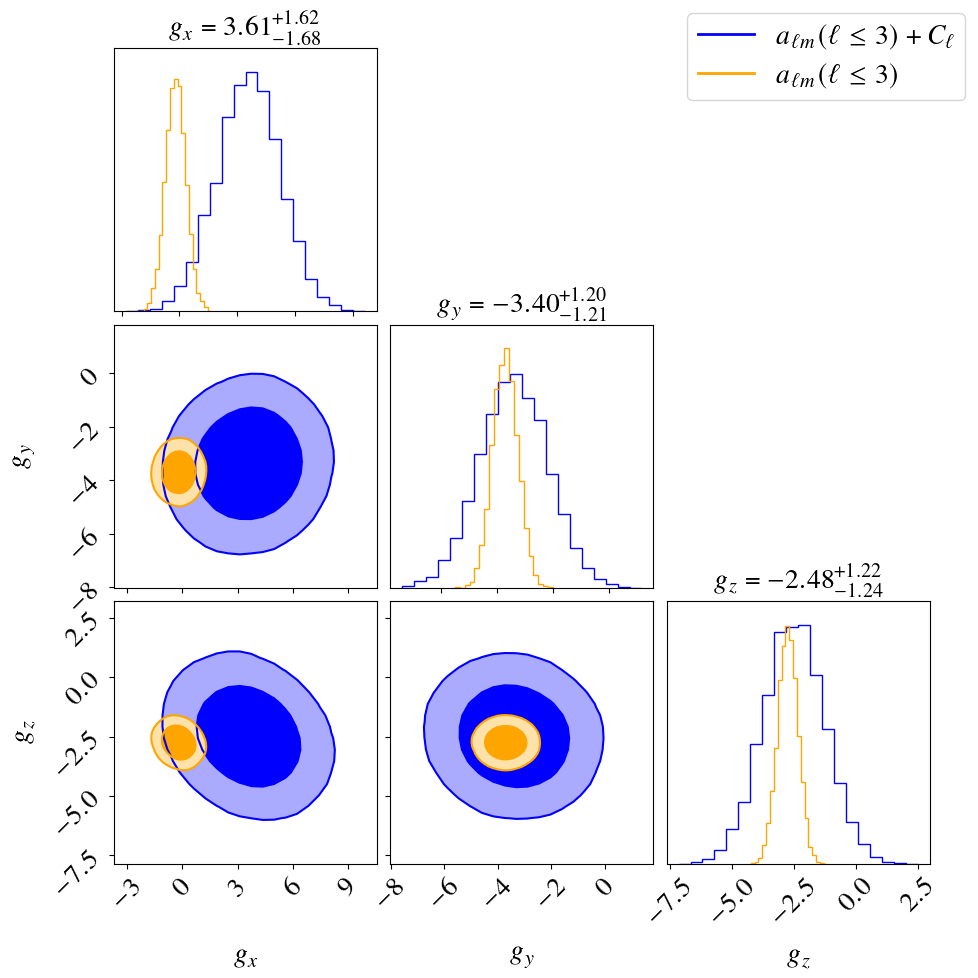

In [92]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

# Full model corner
corner.corner(
    g_full,
    labels=[r'$g_x$', r'$g_y$', r'$g_z$'],
    show_titles=True,
    color='blue',
    fig=fig,
    plot_datapoints=False,
    fill_contours=True,
    plot_contours=True,
    levels=[0.68, 0.95],
    hist=False,
    smooth = 1.5,
    hist2d_kwargs={'bins': 80, 'density': True},
    title_kwargs={'fontsize': 20, 'pad': 10},
    label_kwargs={'fontsize': 20},

)

# Det. model overplotted
corner.corner(
    g_det,
    labels=[r'$g_x$', r'$g_y$', r'$g_z$'],
    color='orange',
    fig=fig,
    plot_datapoints=False,
    fill_contours=True,
    plot_contours=True,
    levels=[0.68, 0.95],
    hist=False,
    smooth = 1.5,
    hist2d_kwargs={'bins': 80, 'density': True},
    label_kwargs={'fontsize': 20},
)

for ax in fig.axes:
    ax.tick_params(labelsize=20) 
    
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='blue',  lw=2, label='$a_{\ell m} (\ell  \leq 3) + C_{\ell}$'),
    Line2D([0], [0], color='orange', lw=2, label='$a_{\ell m} (\ell  \leq 3)$'),
    #Line2D([0], [0], color='red', lw=2, ls='--', label='MAP from data'),
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=20)
plt.savefig('output/gxyz_corner_gaia_galcut_20.pdf', bbox_inches='tight')
plt.show()

In [93]:
import tarp

N_TARP         = 500   # test simulations
N_TARP_SAMPLES = 500   # posterior samples per test point

# ── TARP test simulations: full model (44-dim θ, x shape 240) ────────────────
print(f'Generating {N_TARP} TARP test simulations for full model...')

theta_tarp_full = prior_full.sample((N_TARP,))          # (N_TARP, 44)
x_tarp_full     = torch.stack([
    sim_full_wrapped(theta_tarp_full[i])
    for i in range(N_TARP)
])                                                       # (N_TARP, 240)

print(f'theta_tarp_full: {theta_tarp_full.shape}')
print(f'x_tarp_full:     {x_tarp_full.shape}')

Generating 500 TARP test simulations for full model...
theta_tarp_full: torch.Size([500, 44])
x_tarp_full:     torch.Size([500, 240])


In [94]:
# ── Posterior samples: full model ────────────────────────────────────────────
print(f'Drawing {N_TARP_SAMPLES} posterior samples for {N_TARP} test sims (full model)...')
with torch.no_grad():
    samples_tarp_full = torch.stack([
        posterior_full.sample((N_TARP_SAMPLES,), x=x_tarp_full[i])
        for i in range(N_TARP)
    ], dim=1)   # (N_TARP_SAMPLES, N_TARP, 44)
print(f'samples_tarp_full: {samples_tarp_full.shape}')

Drawing 500 posterior samples for 500 test sims (full model)...


Drawing 500 posterior samples: 700it [00:02, 269.16it/s]                        
Drawing 500 posterior samples: 672it [00:01, 579.35it/s]                         
Drawing 500 posterior samples: 744it [00:04, 158.45it/s]                        
Drawing 500 posterior samples: 548it [00:04, 127.19it/s]                        
Drawing 500 posterior samples: 654it [00:01, 467.43it/s]                        
Drawing 500 posterior samples: 705it [00:01, 681.73it/s]                         
Drawing 500 posterior samples: 683it [00:01, 564.52it/s]                         
Drawing 500 posterior samples: 517it [00:29, 17.68it/s]                         
Drawing 500 posterior samples: 504it [00:03, 126.38it/s]                       
Drawing 500 posterior samples: 684it [00:01, 488.31it/s]                        
Drawing 500 posterior samples: 778it [00:02, 370.55it/s]                        
Drawing 500 posterior samples: 719it [00:01, 404.05it/s]                        
Drawing 500 posterior samp

samples_tarp_full: torch.Size([500, 500, 44])


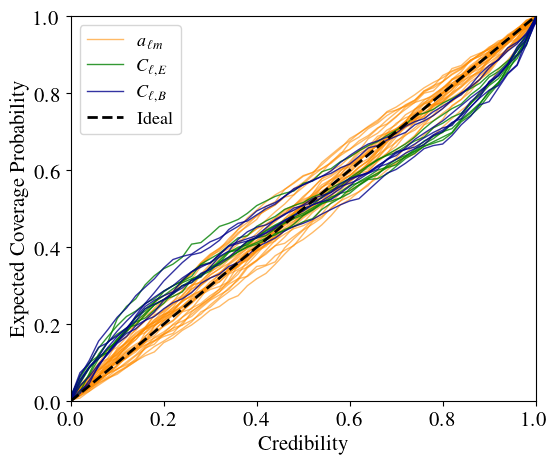

In [95]:
# ── TARP ECP: full model — all 44 parameters, colored by group ───────────────

def marginal_coverage(samples_k, theta_k, n_bins=50):
    alphas = np.linspace(0, 1, n_bins + 1)
    ecp = np.zeros(n_bins + 1)
    for i, a in enumerate(alphas):
        quantiles = np.quantile(samples_k, a, axis=0)
        ecp[i] = np.mean(theta_k < quantiles)
    return alphas, ecp

samples_np = samples_tarp_full.numpy()   # (N_TARP_SAMPLES, N_TARP, 44)
theta_np   = theta_tarp_full.numpy()     # (N_TARP, 44)

groups = [
    (r'$a_{\ell m}$',    range(0, n_alm_l3),          'darkorange', 0.6),
    (r'$C_{\ell,E}$',    range(n_alm_l3, n_alm_l3+7), 'green',      0.8),
    (r'$C_{\ell,B}$',    range(n_alm_l3+7, n_theta),  'darkblue',   0.8),
]

plt.figure(figsize=(6, 5))
for group_name, idx_range, color, alpha_val in groups:
    for k in idx_range:
        alphas_k, ecp_k = marginal_coverage(samples_np[:, :, k], theta_np[:, k])
        lbl = group_name if k == idx_range.start else None
        plt.plot(alphas_k, ecp_k, color=color, alpha=alpha_val, linewidth=1, label=lbl)

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Ideal')
plt.xlabel('Credibility', fontsize=15)
plt.ylabel('Expected Coverage Probability', fontsize=15)
plt.tick_params(labelsize=15)
plt.xlim(0, 1); plt.ylim(0, 1)
plt.legend(fontsize=13)
import os; os.makedirs('output', exist_ok=True)
#plt.savefig('output/tarp_ecp_full_model.pdf', bbox_inches='tight')
plt.show()

Extracting gx,gy,gz from TARP samples...


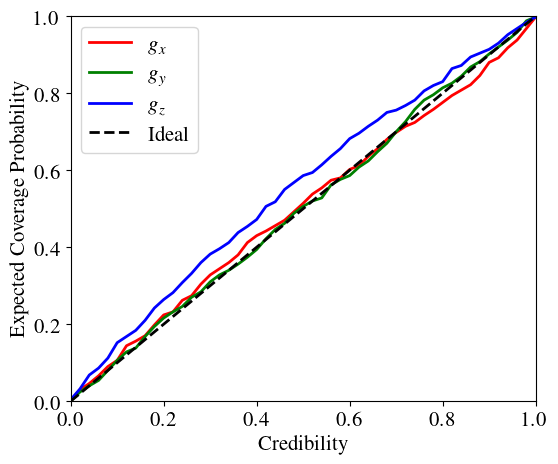

In [96]:
dipole_idx_tarp = np.array([0, lmax_sig, lmax_sig + 1])

def extract_g_tarp(arr_np):
    N_S, N_T, _ = arr_np.shape
    out = np.zeros((N_S, N_T, 3))
    for i in range(N_S):
        for j in range(N_T):
            out[i, j] = skyfunc.s2g(arr_np[i, j, dipole_idx_tarp] * 1e3)
    return out

def extract_g_theta(theta_np):
    return np.array([skyfunc.s2g(theta_np[j, dipole_idx_tarp] * 1e3)
                     for j in range(theta_np.shape[0])])

def marginal_coverage(samples_k, theta_k, n_bins=50):
    alphas = np.linspace(0, 1, n_bins + 1)
    ecp = np.zeros(n_bins + 1)
    for i, a in enumerate(alphas):
        quantiles = np.quantile(samples_k, a, axis=0)
        ecp[i] = np.mean(theta_k < quantiles)
    return alphas, ecp

print('Extracting gx,gy,gz from TARP samples...')
samples_g = extract_g_tarp(samples_tarp_full.numpy())
theta_g   = extract_g_theta(theta_tarp_full.numpy())

# ── Plot 1: marginal coverage per dipole component ───────────────────────────
plt.figure(figsize=(6, 5))
colors  = ['red', 'green', 'blue']
g_names = ['$g_x$', '$g_y$', '$g_z$']
for k, (name, color) in enumerate(zip(g_names, colors)):
    alphas, ecp_k = marginal_coverage(samples_g[:, :, k], theta_g[:, k])
    plt.plot(alphas, ecp_k, color=color, linewidth=2, label=name)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Ideal')
plt.xlabel('Credibility', fontsize=15)
plt.ylabel('Expected Coverage Probability', fontsize=15)
plt.tick_params(labelsize=15)
#plt.title('Marginal coverage - dipole (gx, gy, gz)', fontsize=13)
plt.xlim(0, 1); plt.ylim(0, 1)
plt.legend(fontsize=15)
import os; os.makedirs('output', exist_ok=True)
#plt.savefig('output/tarp_ecp_dipole_gaia.pdf', bbox_inches='tight')
plt.show()


## 12. Bootstrap Resampling

Parametric bootstrap: reconstruct the best-fit ℓ≤3 signal map, then repeatedly add
independent noise realisations drawn from the observed per-pixel covariance and refit.
The spread of the resulting (gx, gy, gz) estimates gives a frequentist confidence region
that can be compared directly with the SBI posterior.

In [127]:
# ── Bootstrap: parametric noise resampling ───────────────────────────────────
# Reconstruct the best-fit ℓ≤3 signal maps from the VSH fit to real data
E_sig_best, B_sig_best = real_to_complex_alm(best_fit_l3, lmax_sig)
m_theta_sig, m_phi_sig = hp.alm2map_spin(
    [E_sig_best, B_sig_best], nside, spin=1, lmax=lmax_sig
)
pmra_signal  =  m_phi_sig
pmdec_signal = -m_theta_sig

N_bootstrap = 10000
g_boot = np.zeros((N_bootstrap, 3))

print(f"Running {N_bootstrap} bootstrap realisations …")
for i in range(N_bootstrap):
    noise_ra, noise_dec = generate_pixel_noise()
    alm_boot = solve_fast(pmra_signal + noise_ra, pmdec_signal + noise_dec, lmax=lmax_sig)
    g_boot[i] = skyfunc.s2g(alm_boot[dipole_idx] * 1e3)
    if (i + 1) % 500 == 0:
        print(f"  {i + 1}/{N_bootstrap}")

q16, q50, q84 = np.percentile(g_boot, [16, 50, 84], axis=0)
print("\nBootstrap (µas/yr):")
for i, lab in enumerate(['gx', 'gy', 'gz']):
    print(f"  {lab} = {q50[i]:.2f}  +{q84[i]-q50[i]:.2f}  -{q50[i]-q16[i]:.2f}")

Running 10000 bootstrap realisations …
  500/10000
  1000/10000
  1500/10000
  2000/10000
  2500/10000
  3000/10000
  3500/10000
  4000/10000
  4500/10000
  5000/10000
  5500/10000
  6000/10000
  6500/10000
  7000/10000
  7500/10000
  8000/10000
  8500/10000
  9000/10000
  9500/10000
  10000/10000

Bootstrap (µas/yr):
  gx = -0.69  +0.80  -0.80
  gy = -3.12  +0.58  -0.56
  gz = -2.82  +0.57  -0.57


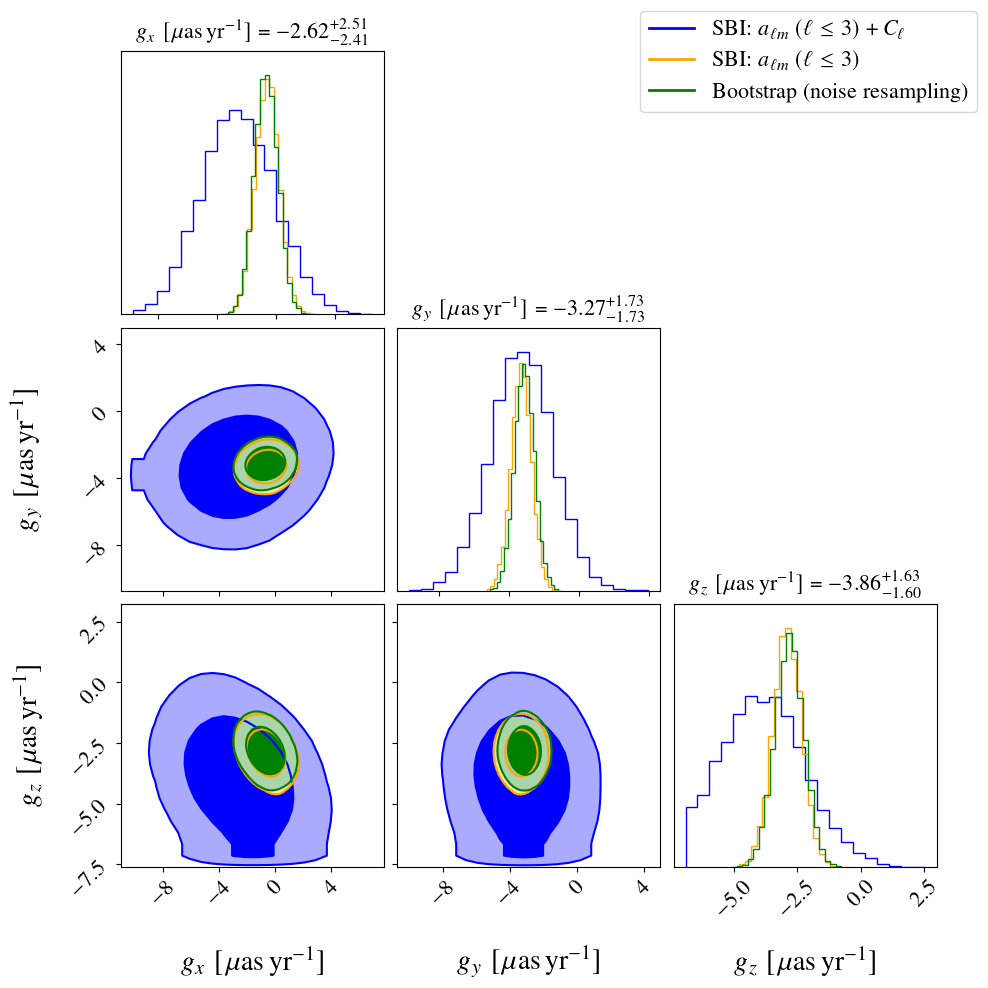

In [128]:
# ── Corner plot: Bootstrap vs SBI posteriors ─────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

corner_kw = dict(
    labels=[r'$g_x\ [\mu\mathrm{as\,yr}^{-1}]$',
             r'$g_y\ [\mu\mathrm{as\,yr}^{-1}]$',
             r'$g_z\ [\mu\mathrm{as\,yr}^{-1}]$'],
    fig=fig,
    plot_datapoints=False,
    fill_contours=True,
    plot_contours=True,
    levels=[0.68, 0.95],
    smooth=1.5,
    hist2d_kwargs={'bins': 80, 'density': True},
    label_kwargs={'fontsize': 20},
)

corner.corner(g_full,  color='blue',   show_titles=True,
              title_kwargs={'fontsize': 16, 'pad': 10}, **corner_kw)
corner.corner(g_det,   color='orange', **corner_kw)
corner.corner(g_boot,  color='green',  **corner_kw)

for ax in fig.axes:
    ax.tick_params(labelsize=16)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='blue',   lw=2,
           label=r'SBI: $a_{\ell m}\,(\ell\leq 3)+C_\ell$'),
    Line2D([0], [0], color='orange', lw=2,
           label=r'SBI: $a_{\ell m}\,(\ell\leq 3)$'),
    Line2D([0], [0], color='green',  lw=2,
           label=r'Bootstrap (noise resampling)'),
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=16)
#plt.savefig('output/gxyz_corner_gaia_galcut_20_bootstrap_vs_sbi.pdf', bbox_inches='tight')
plt.show()

## 13. Posterior Covariance Analysis: Model 1 vs Model 2

**Model 1** — VSH coefficients ℓ≤3 only (deterministic dipole + noise) → `g_det`  
**Model 2** — VSH coefficients ℓ≤3 + stochastic isotropic C_ℓ at ℓ=4–10 → `g_full`

Computes the 3×3 covariance and correlation matrices, marginal inflation factors,
the ratio matrix **R** = C₂ C₁⁻¹ and its eigenvalues (isotropy test), and flags
newly introduced off-diagonal degeneracies.

In [ ]:
#save the poterior samples to a file for later analysis
#np.savez('output/gxyz_posterior_samples_gaia_galcut_30.npz', g_full=g_full, g_det=g_det, g_boot=g_boot)



In [130]:
# ── Use current run samples directly ─────────────────────────────────────────
# Model 1: alm ℓ≤3 only  |  Model 2: alm ℓ≤3 + stochastic Cℓ (ℓ=4..10)
s1 = g_det    # shape (N, 3)  — deterministic SBI posterior
s2 = g_full   # shape (N, 3)  — full SBI posterior

labels_g  = ['gx', 'gy', 'gz']
pairs_idx = [(0, 1, 'gx,gy'), (0, 2, 'gx,gz'), (1, 2, 'gy,gz')]

print(f"Model 1 samples: {s1.shape}  |  Model 2 samples: {s2.shape}")

Model 1 samples: (10000, 3)  |  Model 2 samples: (10000, 3)


In [131]:
# ── Steps 2–4: Covariance, inflation, R matrix, correlations ─────────────────

def cov_to_corr(C):
    sigma = np.sqrt(np.diag(C))
    return C / np.outer(sigma, sigma)

# Step 2 — covariance matrices
C1     = np.cov(s1.T)                        # (3,3)
C2     = np.cov(s2.T)                        # (3,3)
sig1   = np.sqrt(np.diag(C1))
sig2   = np.sqrt(np.diag(C2))
inflation = sig2 / sig1

# Step 3 — ratio matrix R and eigenvalues
R          = C2 @ np.linalg.inv(C1)
ev         = np.sort(np.linalg.eigvals(R).real)
iso_ratio  = ev.max() / ev.min()

# Step 4 — correlation matrices
corr1 = cov_to_corr(C1)
corr2 = cov_to_corr(C2)
diff  = corr2 - corr1

# ── Print ─────────────────────────────────────────────────────────────────────
print("Marginal standard deviations (µas/yr):")
for k, lab in enumerate(labels_g):
    print(f"  {lab}: σ(M1) = {sig1[k]:.3f}   σ(M2) = {sig2[k]:.3f}   "
          f"inflation = {inflation[k]:.3f}")

print(f"\nEigenvalues of R: {ev[0]:.3f}  {ev[1]:.3f}  {ev[2]:.3f}")
print(f"Isotropy ratio λmax/λmin: {iso_ratio:.3f}")

print(f"\n{'Pair':<10} {'M1':>8} {'M2':>8} {'Diff':>8}  Flag")
print("─" * 45)
for i, j, name in pairs_idx:
    r1, r2 = corr1[i, j], corr2[i, j]
    d      = r2 - r1
    flag   = '⚑ NEW DEGENERACY' if (abs(r2) > 0.3 and abs(d) > 0.15) else ''
    print(f"{name:<10} {r1:>8.3f} {r2:>8.3f} {d:>8.3f}  {flag}")

Marginal standard deviations (µas/yr):
  gx: σ(M1) = 0.814   σ(M2) = 2.457   inflation = 3.018
  gy: σ(M1) = 0.582   σ(M2) = 1.753   inflation = 3.011
  gz: σ(M1) = 0.567   σ(M2) = 1.569   inflation = 2.769

Eigenvalues of R: 7.463  8.910  9.700
Isotropy ratio λmax/λmin: 1.300

Pair             M1       M2     Diff  Flag
─────────────────────────────────────────────
gx,gy         0.138    0.201    0.063  
gx,gz        -0.356   -0.303    0.053  
gy,gz        -0.015   -0.065   -0.050  


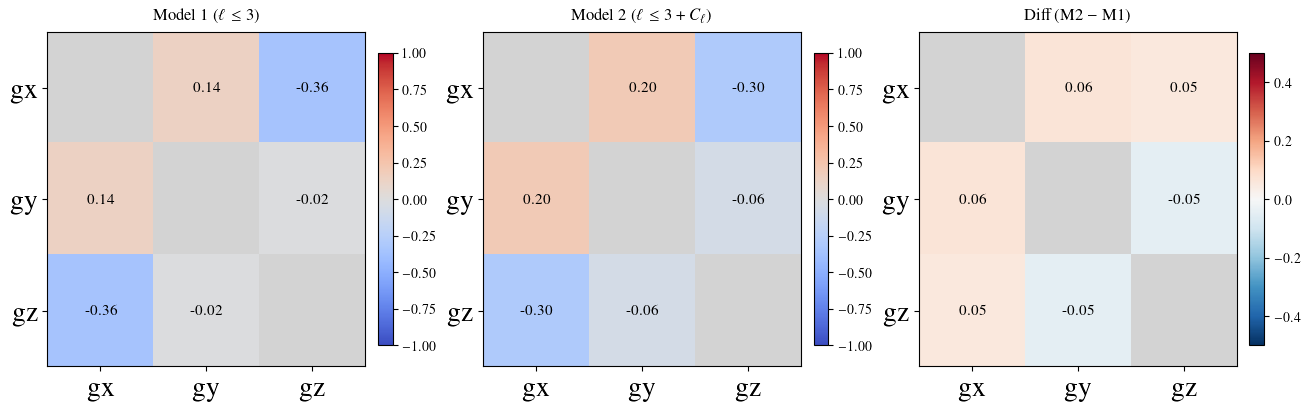

In [133]:
# ── Figure 1: Correlation matrix panels ──────────────────────────────────────
import matplotlib.patches as mpatches

diff_vmax = 0.5
if np.abs(diff).max() > 0.5:
    diff_vmax = float(np.ceil(np.abs(diff).max() * 10) / 10)
    print(f"WARNING: max |diff| = {np.abs(diff).max():.3f} -- extending range to +/-{diff_vmax:.1f}")

def mask_diag(M):
    """Return a copy with diagonal set to NaN so imshow shows them as masked."""
    out = M.astype(float).copy()
    np.fill_diagonal(out, np.nan)
    return out

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)

panels = [
    (mask_diag(corr1), r'Model 1  ($\ell \leq 3$)',          'coolwarm', -1,         1),
    (mask_diag(corr2), r'Model 2  ($\ell \leq 3 + C_\ell$)', 'coolwarm', -1,         1),
    (mask_diag(diff),  r'Diff  (M2 $-$ M1)',                  'RdBu_r',  -diff_vmax, diff_vmax),
]

for ax, (data, title, cmap, vmin, vmax) in zip(axes, panels):
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color='lightgrey')
    im = ax.imshow(data, vmin=vmin, vmax=vmax, cmap=cmap_obj, aspect='auto')
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.tick_params(labelsize=10)
    ax.set_xticks([0, 1, 2]);  ax.set_xticklabels(labels_g, fontsize=20)
    ax.set_yticks([0, 1, 2]);  ax.set_yticklabels(labels_g, fontsize=20)
    ax.set_title(title, fontsize=12, pad=8)
    for i in range(3):
        for j in range(3):
            if i == j:
                continue   # skip diagonal
            val    = data[i, j]
            tcolor = 'white' if abs(val) > 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=11, color=tcolor, fontweight='bold')

# Bold red border on diff panel for |diff| > 0.2 (off-diagonal only)
for i in range(3):
    for j in range(3):
        if i != j and abs(diff[i, j]) > 0.2:
            rect = mpatches.FancyBboxPatch(
                (j - 0.49, i - 0.49), 0.98, 0.98,
                linewidth=3, edgecolor='red', facecolor='none',
                boxstyle='square,pad=0', transform=axes[2].transData,
            )
            axes[2].add_patch(rect)

#fig.suptitle(r'Correlation matrices -- Gaia EDR3 (20$^\circ$ galactic mask)', fontsize=13)
#plt.savefig('output/correlation_matrix_panels_gaia.pdf', dpi=300, bbox_inches='tight')
plt.show()

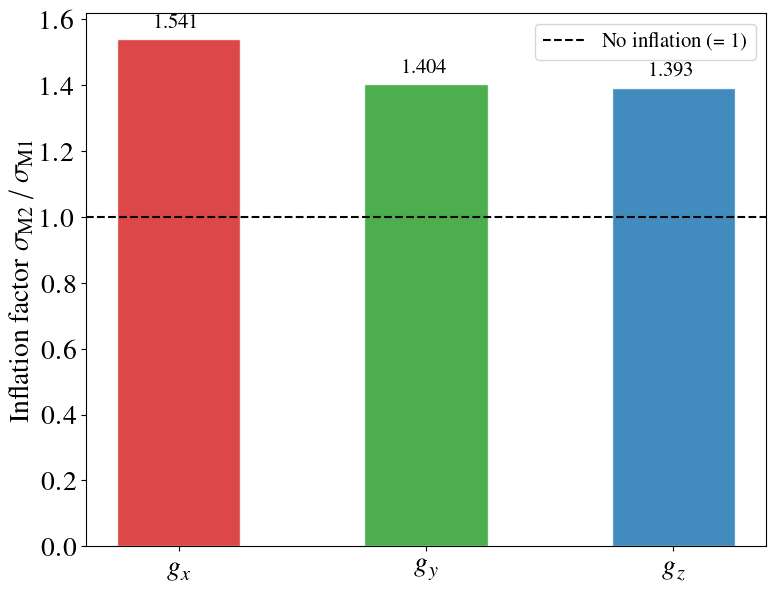

In [ ]:
# ── Figure 2: Inflation factor bar chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#d62728', '#2ca02c', '#1f77b4']
x      = np.arange(3)

bars = ax.bar(x, inflation, color=colors, alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars, inflation):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=15, fontweight='bold')

ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='No inflation (= 1)')
#ax.axhline(1.5, color='grey',  linestyle='--', linewidth=1.0, label='Moderate threshold (= 1.5)')

ax.set_xticks(x)
ax.set_xticklabels([r'$g_x$', r'$g_y$', r'$g_z$'], fontsize=20)
ax.set_ylabel(r'Inflation factor  $\sigma_{\rm M2}\,/\,\sigma_{\rm M1}$', fontsize=20)
#ax.set_title(r'Uncertainty inflation  ($\iota = ' + f'{iso_ratio:.2f}$)', fontsize=13)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.legend(fontsize=15)
ax.set_ylim(bottom=0)
plt.tight_layout()
#plt.savefig('output/inflation_factors_gaia.pdf', bbox_inches='tight')
plt.show()

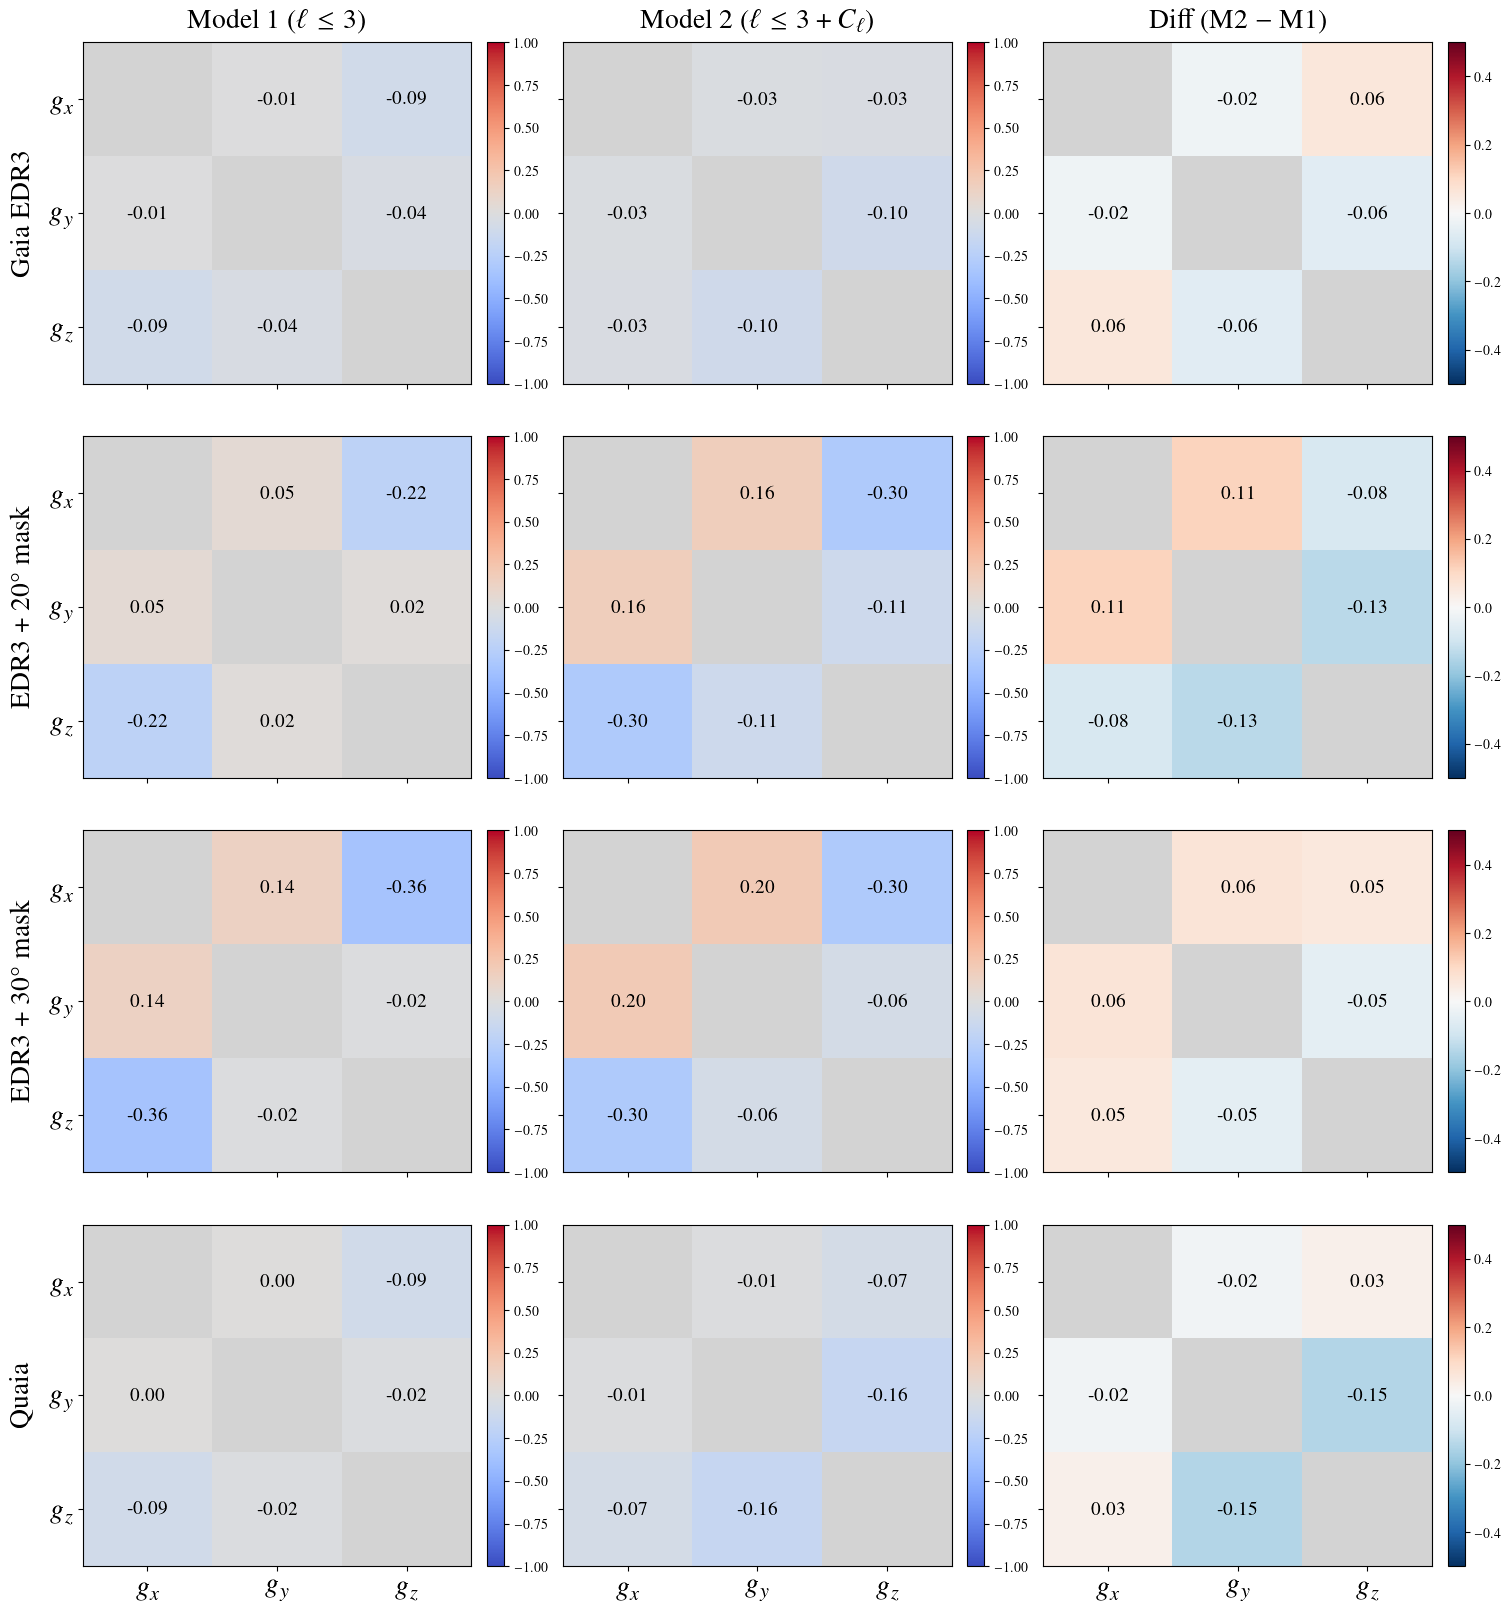

In [145]:
# Load posteriors from saved files
npz_files = {
    'Gaia EDR3':        'output/gxyz_posterior_samples_gaia.npz',
    'EDR3 + 20° mask':  'output/gxyz_posterior_samples_gaia_galcut_20.npz',
    'EDR3 + 30° mask':  'output/gxyz_posterior_samples_gaia_galcut_30.npz',
    'Quaia':            'output/gxyz_posterior_samples_quaia.npz',
}
row_labels = list(npz_files.keys())

def cov_to_corr(C):
    sigma = np.sqrt(np.diag(C))
    return C / np.outer(sigma, sigma)

def mask_diag(M):
    out = M.astype(float).copy()
    np.fill_diagonal(out, np.nan)
    return out

# Build correlation matrices for all configs
corr1_all, corr2_all, diff_all = {}, {}, {}
for label, path in npz_files.items():
    d  = np.load(path)
    c1 = cov_to_corr(np.cov(d['g_det'].T))
    c2 = cov_to_corr(np.cov(d['g_full'].T))
    corr1_all[label] = c1
    corr2_all[label] = c2
    diff_all[label]  = c2 - c1

diff_vmax = 0.5
global_max_diff = max(np.abs(diff_all[lb]).max() for lb in row_labels)
if global_max_diff > 0.5:
    diff_vmax = float(np.ceil(global_max_diff * 10) / 10)
    print(f"WARNING: max |diff| = {global_max_diff:.3f} -- extending range to +/-{diff_vmax:.1f}")

labels_g = [r'$g_x$', r'$g_y$', r'$g_z$']
col_titles = [
    r'Model 1  ($\ell \leq 3$)',
    r'Model 2  ($\ell \leq 3 + C_\ell$)',
    r'Diff  (M2 $-$ M1)',
]
cmaps  = ['coolwarm', 'coolwarm', 'RdBu_r']
vmins  = [-1, -1, -diff_vmax]
vmaxs  = [ 1,  1,  diff_vmax]

# No sharey — imshow axes each have independent pixel coords [0,1,2]
# We manually hide tick labels on cols 1 and 2
fig, axes = plt.subplots(4, 3, figsize=(15, 16),
                         sharex='col',
                         constrained_layout=True)
fig.get_layout_engine().set(hspace=0.1)  # increase for more space, decrease for less


for row, label in enumerate(row_labels):
    data_panels = [
        mask_diag(corr1_all[label]),
        mask_diag(corr2_all[label]),
        mask_diag(diff_all[label]),
    ]
    for col, (data, cmap, vmin, vmax) in enumerate(zip(data_panels, cmaps, vmins, vmaxs)):
        ax = axes[row, col]
        cmap_obj = plt.get_cmap(cmap).copy()
        cmap_obj.set_bad(color='lightgrey')
        im = ax.imshow(data, vmin=vmin, vmax=vmax, cmap=cmap_obj, aspect='auto')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # x ticks — shown on all panels (sharex handles bottom row only)
        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels(labels_g, fontsize=20)

        # y ticks — always set, but labels only on col 0
        ax.set_yticks([0, 1, 2])
        if col == 0:
            ax.set_yticklabels(labels_g, fontsize=20)
            ax.set_ylabel(label, fontsize=20, fontweight='bold', labelpad=10)
        else:
            ax.tick_params(axis='y', left=True, labelleft=False)

        # Column titles on first row only
        if row == 0:
            ax.set_title(col_titles[col], fontsize=20, pad=10)

        # Annotate off-diagonal cells
        for i in range(3):
            for j in range(3):
                if i == j:
                    continue
                val    = data[i, j]
                tcolor = 'white' if abs(val) > 0.6 else 'black'
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=14, color=tcolor, fontweight='bold')

        # Red border on diff column for |diff| > 0.2
        if col == 2:
            raw_diff = diff_all[label]
            for i in range(3):
                for j in range(3):
                    if i != j and abs(raw_diff[i, j]) > 0.2:
                        rect = mpatches.FancyBboxPatch(
                            (j - 0.49, i - 0.49), 0.98, 0.98,
                            linewidth=3, edgecolor='red', facecolor='none',
                            boxstyle='square,pad=0', transform=ax.transData,
                        )
                        ax.add_patch(rect)

plt.savefig('output/correlation_matrix_panels.pdf', dpi=300, bbox_inches='tight')
plt.show()

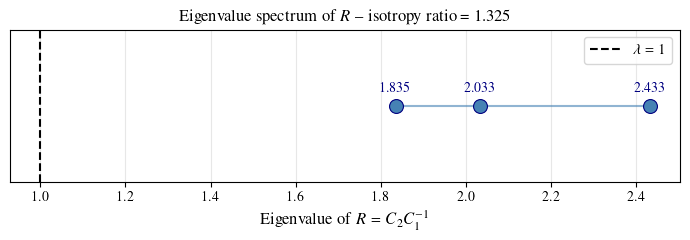

In [78]:
# ── Figure 4: Eigenvalue spectrum of R ───────────────────────────────────────
use_log = (ev.max() / max(ev.min(), 1e-9)) > 5

fig, ax = plt.subplots(figsize=(7, 2.5))

ax.scatter(ev, [0, 0, 0], s=100, zorder=3, color='steelblue', edgecolors='navy', lw=0.8)
ax.hlines(0, ev.min(), ev.max(), color='steelblue', lw=1.5, alpha=0.6)
for val in ev:
    ax.annotate(f'{val:.3f}', (val, 0), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=10, color='navy')

ax.axvline(1.0, color='black', linestyle='--', linewidth=1.5, label=r'$\lambda = 1$')
ax.set_yticks([])
if use_log:
    ax.set_xscale('log')
    ax.set_xlabel(r'Eigenvalue of $R = C_2 C_1^{-1}$ (log scale)', fontsize=12)
else:
    ax.set_xlabel(r'Eigenvalue of $R = C_2 C_1^{-1}$', fontsize=12)

ax.set_title(r'Eigenvalue spectrum of $R$ -- isotropy ratio = ' + f'{iso_ratio:.3f}', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
#plt.savefig('output/eigenvalue_spectrum.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# ── Step 7: Isotropy test summary ────────────────────────────────────────────
print("ISOTROPY TEST SUMMARY")
print("=" * 53)
print("Configuration: Gaia EDR3 — 20° galactic mask")
print()
for k, lab in enumerate(labels_g):
    print(f"  Inflation  {lab}: {inflation[k]:.3f}")
print(f"\n  Isotropy ratio (λmax/λmin): {iso_ratio:.3f}")

largest_new = max(abs(diff[i, j]) for i, j, _ in pairs_idx)
print(f"  Largest |Δρ| off-diagonal : {largest_new:.3f}")

flags = [
    (name, corr2[i, j], diff[i, j])
    for i, j, name in pairs_idx
    if abs(corr2[i, j]) > 0.3 and abs(diff[i, j]) > 0.15
]
for name, r2, d in flags:
    print(f"  ⚑ New degeneracy: ρ({name}) = {r2:.3f}  (Δρ = {d:+.3f})")

print()
max_comp = labels_g[int(np.argmax(inflation))]
if iso_ratio < 1.5:
    print(f"→ PASS: Inflation is approximately isotropic (ratio = {iso_ratio:.2f} < 1.5), "
          "consistent with the isotropic Cℓ assumption.")
else:
    print(f"→ FLAG: Inflation is anisotropic (ratio = {iso_ratio:.2f}), suggesting the "
          f"isotropic Cℓ model preferentially inflates the {max_comp} direction. "
          "This should be discussed in the paper.")

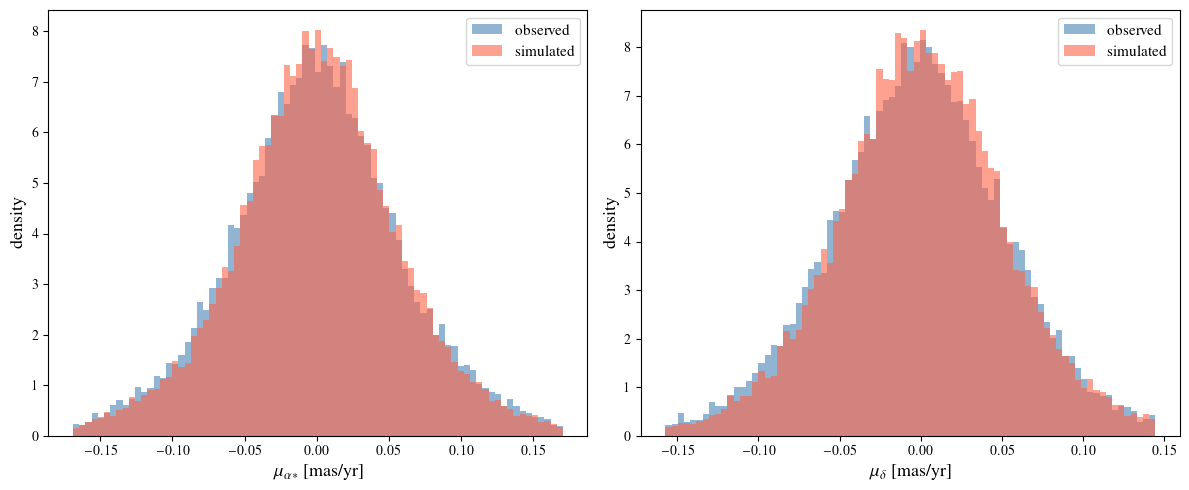

In [83]:
median_theta = np.median(samples_full_np, axis=0)
Cl_E_fid = median_theta[n_alm_l3 : n_alm_l3 + n_Cl // 2]
Cl_B_fid = median_theta[n_alm_l3 + n_Cl // 2 :]

Cl_E_full = np.zeros(lmax_fit + 1)
Cl_B_full = np.zeros(lmax_fit + 1)
Cl_E_full[4:11] = np.maximum(Cl_E_fid, 0)
Cl_B_full[4:11] = np.maximum(Cl_B_fid, 0)

alm_E_sig = hp.synalm(Cl_E_full, lmax=lmax_fit)
alm_B_sig = hp.synalm(Cl_B_full, lmax=lmax_fit)
m_theta, m_phi = hp.alm2map_spin([alm_E_sig, alm_B_sig], nside, spin=1, lmax=lmax_fit)
pmra_sig  =  m_phi
pmdec_sig = -m_theta

noise_ra, noise_dec = generate_pixel_noise()
pmra_sim_obs  = pmra_sig  + noise_ra
pmdec_sim_obs = pmdec_sig + noise_dec

# ── Compare histograms over valid pixels ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, obs_map, sim_map, xlabel in [
    (axes[0], gaia_pmra_wm[valid_pix],  pmra_sim_obs[valid_pix],
     r'$\mu_{\alpha*}$ [mas/yr]'),
    (axes[1], gaia_pmdec_wm[valid_pix], pmdec_sim_obs[valid_pix],
     r'$\mu_{\delta}$ [mas/yr]'),
]:
    lo = np.percentile(obs_map, 1)
    hi = np.percentile(obs_map, 99)
    bins = np.linspace(lo, hi, 80)
    ax.hist(obs_map, bins=bins, density=True, alpha=0.6,
            color='steelblue', label='observed')
    ax.hist(sim_map, bins=bins, density=True, alpha=0.6,
            color='tomato',    label='simulated')
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel('density', fontsize=13)
    ax.legend(fontsize=11)

plt.tight_layout()
plt.show()